# nb_04 — Lomb-Scargle periods

Goal (see `docs/SPEC_V01.md`, rough plan step 4): run a Lomb-Scargle periodogram per object,
per band, using each light curve's duration (from nb_02) to bound the search's longest
findable period. Measure execution time — the spec flags this explicitly, since periods are
one of the more expensive things this workshop asks for. Works on nb_03's
`dia_object_lc_10plus_with_mags`.


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

import lsdb
from datapaths import Datapaths

dp = Datapaths()
subset_cat = lsdb.open_catalog(dp["dp2_subset"] / "dia_object_lc_10plus_with_mags")
print(subset_cat.npartitions, "partitions")
subset_cat


4 partitions


,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource,field,duration_days,median_cadence_gap_days,u_amp_p90p10,g_amp_p90p10,r_amp_p90p10,i_amp_p90p10,z_amp_p90p10,y_amp_p90p10,u_mag_median,g_mag_median,r_mag_median,i_mag_median,z_mag_median,y_mag_median,max_reliability
npartitions=4,,,,,,,,,,,,,,,,,,,,,,,
"Order: 1, Pixel: 17",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ...",string[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 1, Pixel: 34",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 1, Pixel: 41",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 1, Pixel: 47",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


## 1. Per-band Lomb-Scargle via `map_rows`

Same `map_rows(..., append_columns=True)` pattern as nb_02/nb_03, this time running
`astropy.timeseries.LombScargle` on `diaSource.scienceMag` vs. `diaSource.midpointMjdTai`, per
band (bands don't share a cadence, so mixing them isn't meaningful — same reasoning as nb_02's
amplitude stats).

**Longest findable period, from nb_02's `duration_days`:** at least ~2 cycles need to fit in
the observed baseline to say anything about a period, so `maximum_period = duration_days / 2`,
passed to `LombScargle.autopower` as `minimum_frequency`. The *shortest* findable period is left
to `autopower`'s own default (`samples_per_peak=5`, `nyquist_factor=5`, both astropy defaults) —
this subset's per-object cadence is uneven enough that a fixed floor didn't seem worth adding
on top of the default.

**A real-data finding that shapes the threshold below:** per-band point counts in this subset
are much thinner than `nDiaSources` (the *total* across all 6 bands) suggests — median counts
per band are `z`: 7, `i`: 3, `r`: 3, `g`: 2, `u`/`y`: 0. Only ~34% of objects reach 10+ points
in their best band at all. `MIN_POINTS_FOR_LS = 10` below is already a compromise — lower and
the periodogram is mostly noise, higher and there's barely anything left to plot. Expect most
objects to end up with `NaN` periods in most bands, and `z` to dominate the objects that do get
one (it happens to be the best-sampled band for this particular subset — notably not `r`, which
nb_01 used as the depth/cadence proxy for picking these fields in the first place).


In [2]:
BANDS = "ugrizy"
MIN_POINTS_FOR_LS = 10
LS_KWARGS = dict(samples_per_peak=5, nyquist_factor=5)


def band_periods(row):
    t_all = np.asarray(row["diaSource.midpointMjdTai"], dtype=float)
    mag_all = np.asarray(row["diaSource.scienceMag"], dtype=float)
    band_all = np.asarray(row["diaSource.band"])

    duration = row["duration_days"]
    max_period = duration / 2 if duration and duration > 0 else np.nan

    out = {}
    best_period, best_power = np.nan, -np.inf
    for b in BANDS:
        sel = (band_all == b) & np.isfinite(mag_all) & np.isfinite(t_all)
        t, mag = t_all[sel], mag_all[sel]

        if len(t) < MIN_POINTS_FOR_LS or not np.isfinite(max_period) or max_period <= 0:
            out[f"{b}_period_days"] = np.nan
            out[f"{b}_period_power"] = np.nan
            continue

        freq, power = LombScargle(t, mag).autopower(minimum_frequency=1.0 / max_period, **LS_KWARGS)
        i = np.argmax(power)
        out[f"{b}_period_days"] = float(1.0 / freq[i])
        out[f"{b}_period_power"] = float(power[i])
        if power[i] > best_power:
            best_period, best_power = out[f"{b}_period_days"], out[f"{b}_period_power"]

    out["best_period_days"] = best_period
    out["best_period_power"] = best_power if np.isfinite(best_power) else np.nan
    return pd.Series(out)


meta = {}
for b in BANDS:
    meta[f"{b}_period_days"] = "f8"
    meta[f"{b}_period_power"] = "f8"
meta["best_period_days"] = "f8"
meta["best_period_power"] = "f8"

map_rows_columns = ["duration_days", "diaSource.midpointMjdTai", "diaSource.scienceMag", "diaSource.band"]

t0 = time.time()
with_periods_cat = subset_cat.map_rows(band_periods, columns=map_rows_columns, meta=meta, append_columns=True)
merged_df = with_periods_cat.compute()
elapsed = time.time() - t0

n_obj = len(merged_df)
print(f"{elapsed:.1f} s for {n_obj} objects ({1000 * elapsed / n_obj:.2f} ms/object)")
for b in BANDS:
    print(f"  {b}: {merged_df[f'{b}_period_days'].notna().sum()} periods")
print("any band:", merged_df[[f"{b}_period_days" for b in BANDS]].notna().any(axis=1).sum())


Computing Catalog:   0%|          | 0/8 [00:00<?, ?it/s]

4.2 s for 7036 objects (0.60 ms/object)
  u: 0 periods
  g: 175 periods
  r: 125 periods
  i: 903 periods
  z: 1824 periods
  y: 76 periods
any band: 2373


## 2. Execution time — and what it says about the full collection

The spec calls this out specifically: periods are expensive enough that performance needs
checking before the workshop, not during it. The measurement above is single-machine, serial
(no Dask cluster, no parallel workers) — write it back to `dia_object_lc_10plus_with_periods`
below, then use the per-object rate for a rough extrapolation to `dia_object_collection`'s full
232,004,216 rows (`_metadata` footer count, no data read — same trick nb_01 used).

This is a naive linear projection, not a real estimate: our subset is already filtered to
`nDiaSources > 10`, so most raw-collection objects have far fewer `diaSource` points and would
fail `MIN_POINTS_FOR_LS` almost instantly rather than running a full periodogram — meaning the
real full-collection number is very likely *better* than this projection, not worse. Treat it
as an order-of-magnitude ceiling for planning, not a promise.


In [3]:
FULL_COLLECTION_ROWS = 232_004_216
projected_seconds = FULL_COLLECTION_ROWS * (elapsed / n_obj)
print(f"naive linear projection for the full collection: {projected_seconds / 3600:.1f} hours, serial, single-machine")

with_periods_path = dp["dp2_subset"] / "dia_object_lc_10plus_with_periods"
lsdb.from_dataframe(merged_df).write_catalog(with_periods_path, overwrite=True, create_thumbnail=False, progress_bar=False)
print("wrote", with_periods_path)

dp.register(
    name="dia_object_lc_10plus_with_periods",
    type="dp2_subset",
    fmt="hats-collection",
    src_path=str(with_periods_path / "collection.properties"),
    tags=["nb04", "dp2", "diaObject", "periods", "lomb-scargle"],
    inputs=["dia_object_lc_10plus_with_mags"],
    notes=(
        "dia_object_lc_10plus_with_mags plus {band}_period_days/{band}_period_power (per band, "
        "Lomb-Scargle on diaSource.scienceMag, >=10 points required, max period = duration_days/2) "
        "and best_period_days/best_period_power (highest-power band), from nb_04."
    ),
    overwrite_history=True,
)
dp.print_paths(name="dia_object_lc_10plus_with_periods")


naive linear projection for the full collection: 38.4 hours, serial, single-machine


wrote /home/shrra-ung/share/trieste/dia_object_lc_10plus_with_periods
name                              | path                                                                                  | tags                                    | type       | updated at               
----------------------------------+---------------------------------------------------------------------------------------+-----------------------------------------+------------+--------------------------
dia_object_lc_10plus_with_periods | /home/shrra-ung/share/trieste/dia_object_lc_10plus_with_periods/collection.properties | diaobject,dp2,lomb-scargle,nb04,periods | dp2_subset | 2026-08-29T15:19:57+00:00


## 3. Period histogram

Reopen the written collection, then look at `best_period_days` (whichever band had the
highest-power periodogram for that object) restricted to objects that got one at all.
`best_period_power` isn't a calibrated false-alarm probability — just this periodogram's raw
peak power — so this is "periods LS found," not "periods that are real."


['best_period_days', 'best_period_power', 'dec', 'diaObjectForcedSource', 'diaObjectId', 'diaSource', 'duration_days', 'field', 'g_amp_p90p10', 'g_mag_median', 'g_period_days', 'g_period_power', 'i_amp_p90p10', 'i_mag_median', 'i_period_days', 'i_period_power', 'max_reliability', 'median_cadence_gap_days', 'nDiaSources', 'r_amp_p90p10', 'r_mag_median', 'r_period_days', 'r_period_power', 'ra', 'tract', 'u_amp_p90p10', 'u_mag_median', 'u_period_days', 'u_period_power', 'y_amp_p90p10', 'y_mag_median', 'y_period_days', 'y_period_power', 'z_amp_p90p10', 'z_mag_median', 'z_period_days', 'z_period_power']


Computing Catalog:   0%|          | 0/8 [00:00<?, ?it/s]

(2373, 4)


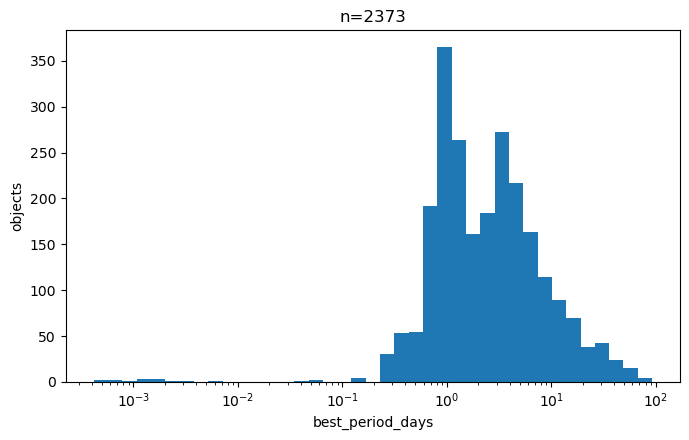

In [4]:
periods_cat = lsdb.open_catalog(dp["dp2_subset"] / "dia_object_lc_10plus_with_periods")
print(sorted(periods_cat.columns))

periods_df = periods_cat[["diaObjectId", "field", "best_period_days", "best_period_power"]].compute()
periods_df = periods_df.dropna(subset=["best_period_days"])
print(periods_df.shape)

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.logspace(np.log10(periods_df["best_period_days"].min()), np.log10(periods_df["best_period_days"].max()), 40)
ax.hist(periods_df["best_period_days"], bins=bins, color="C0")
ax.set_xscale("log")
ax.set_xlabel("best_period_days")
ax.set_ylabel("objects")
ax.set_title(f"n={len(periods_df)}")
fig.tight_layout()


## 4. Sanity check: fold the highest-power light curve

Take the object with the single highest `best_period_power` in the whole subset, fold its
best band's light curve on that period, and look at it — the same "spot-check, don't trust the
histogram blindly" instinct the spec asks for throughout.


Computing Catalog:   0%|          | 0/8 [00:00<?, ?it/s]

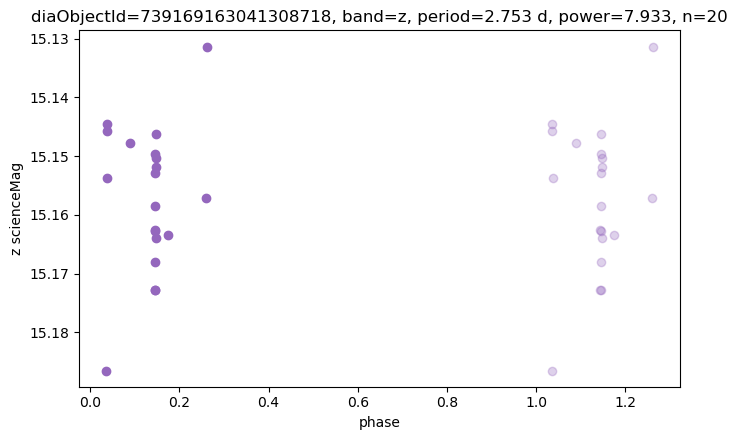

In [5]:
fold_cols = (
    ["diaObjectId", "diaSource", "best_period_days", "best_period_power"]
    + [f"{b}_period_power" for b in BANDS]
)
fold_df = periods_cat[fold_cols].compute()
fold_df = fold_df.dropna(subset=["best_period_days"])

top = fold_df.loc[fold_df["best_period_power"].idxmax()]
# pd.notna() first: per-band *_period_power is a nullable-float column, and `pd.NA == x` raises
# (ambiguous truth value) rather than returning False the way `np.nan == x` would.
best_band = next(
    b for b in BANDS
    if pd.notna(top[f"{b}_period_power"]) and float(top[f"{b}_period_power"]) == float(top["best_period_power"])
)
period = top["best_period_days"]

ds = top["diaSource"]
sel = ds["band"] == best_band
t = ds.loc[sel, "midpointMjdTai"].to_numpy()
mag = ds.loc[sel, "scienceMag"].to_numpy()
phase = (t / period) % 1.0

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(phase, mag, color=f"C{BANDS.index(best_band)}")
ax.scatter(phase + 1, mag, color=f"C{BANDS.index(best_band)}", alpha=0.3)  # second cycle, for continuity
ax.invert_yaxis()
ax.set_xlabel("phase")
ax.set_ylabel(f"{best_band} scienceMag")
ax.set_title(
    f"diaObjectId={top['diaObjectId']}, band={best_band}, "
    f"period={period:.3f} d, power={top['best_period_power']:.3f}, n={sel.sum()}"
)
fig.tight_layout()


## Next

`dia_object_lc_10plus_with_periods` is registered and carries the light curves, nb_02's stats,
nb_03's magnitudes, and now per-band periods (plus a highest-power `best_period_days`) together.

Open questions carried forward, not resolved here:
- **`best_period_power` isn't a false-alarm probability.** It's `LombScargle`'s raw peak power
  under the `standard` normalization — a couple of objects even come out with power above 1.
  Section 4's fold makes this concrete: the single highest-power object in the whole subset
  (`power=7.93`) folds into ~0.05 mag of scatter with no visible periodic shape — almost
  certainly noise the periodogram overfit, not a real signal. A real vetting pass (bootstrap
  FAP, or at least `false_alarm_probability()`) is needed before treating any of these as
  candidates.
- **No aliasing/multi-peak check.** Only the single highest peak is kept per band; the usual
  daily/yearly-alias companions aren't compared against it.
- **Single-band periods only.** `astropy.timeseries.LombScargleMultiband` exists and could
  combine bands properly instead of picking one "best" band per object — not attempted here.
- **`MIN_POINTS_FOR_LS = 10` is a compromise, not a validated choice** — see section 1's
  real-data numbers. Worth revisiting once real candidates need vetting rather than a demo.
- **Execution-time projection is naive** (section 2) — no parallelism, and probably an
  overestimate for the true full collection for the reason given there.
